# Geometry Optimization in SIESTA  
## Theoretical Background

---

## 1. What is Geometry Optimization?

Geometry optimization (also called **structure optimization** or **minimization**) is the process of finding the **most stable atomic structure** of a system.

In quantum-mechanical simulations, different atomic positions correspond to different **total energies**.  
The optimized geometry is the one where:

- The **total energy is minimum**
- The **forces on all atoms are (almost) zero**

This optimized structure represents a physically stable configuration.

---

## 2. Total Energy in Density Functional Theory (DFT)

In Density Functional Theory, the total energy of a system depends on the **electron density**:

$[
E_{\text{total}} = E[\rho(\mathbf{r})]
]$

The total energy includes contributions from:
- Kinetic energy of electrons
- Electron–nucleus interaction
- Electron–electron interaction
- Exchange–correlation effects
- Ion–ion (nucleus–nucleus) interaction

When atoms move, the electron density changes, and therefore the total energy changes.

---

## 3. Forces on Atoms

The **force on an atom** is defined as the negative derivative of the total energy with respect to the atomic position:

$[
\mathbf{F}_I = - \frac{\partial E_{\text{total}}}{\partial \mathbf{R}_I}
]$

- If the force is **non-zero**, the atom is not in equilibrium and wants to move.
- If the force is **zero**, the atom is at an equilibrium position.

Thus, minimizing forces is equivalent to minimizing total energy.

---

## 4. Hellmann–Feynman Forces

SIESTA calculates forces using the **Hellmann–Feynman theorem**.

This theorem states that once the electronic ground state is known, forces on atoms can be computed directly from the electron density without numerical differentiation.

Because SIESTA uses a localized atomic-orbital basis, **Pulay forces** also arise, and SIESTA accounts for them properly.

---

## 5. Energy Landscape Picture

The total energy can be visualized as a **multi-dimensional energy surface**:

- Each atomic coordinate represents one dimension
- Valleys correspond to low-energy configurations
- Hills correspond to unstable configurations

Geometry optimization means **moving downhill on this energy surface** until a local minimum is reached.

---

## 6. Optimization Algorithms in SIESTA

SIESTA uses **iterative optimization algorithms** that update atomic positions step by step using the forces.

### Conjugate Gradient (CG) Method

The most commonly used method is **Conjugate Gradient (CG)**.

Key ideas:
- Uses both current and previous force directions
- Converges faster than simple steepest descent
- Efficient for systems with many atoms

At each step:
1. Forces are calculated
2. A direction is chosen
3. Atoms are moved
4. Energy and forces are recalculated

---

## 7. Convergence Criteria

The optimization stops when predefined conditions are satisfied.

### Force Tolerance

$[
\max(|\mathbf{F}_I|) < \text{MD.MaxForceTol}]$

This means that the largest force acting on any atom is below a chosen threshold.

### Step Limit

A maximum number of optimization steps is set to prevent infinite loops if convergence is slow.

---

## 8. Born–Oppenheimer Approximation

Geometry optimization relies on the **Born–Oppenheimer approximation**, which assumes:

- Electrons adjust instantaneously to atomic motion
- Atoms move on the electronic ground-state energy surface

Thus, at every optimization step:
1. Atomic positions are fixed
2. The electronic ground state is solved
3. Forces are computed
4. Atoms are moved slightly

---

## 10. Importance of Geometry Optimization

Geometry optimization is essential because:

- Non-optimized structures have large forces
- Total energies are not physically meaningful
- Properties such as band structure, DOS, and phonons depend on equilibrium geometry

All reliable first-principles calculations must start from a well-optimized structure.

---

## 11. Summary

- Geometry optimization finds the minimum-energy structure of a system
- It is based on minimizing forces derived from DFT total energy
- SIESTA uses Hellmann–Feynman forces and optimization algorithms like Conjugate Gradient
- Convergence is achieved when forces (and optionally stresses) are sufficiently small
- Optimized structures represent physically stable configurations


# EX1:- Conjugate Gradient

In [2]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH


In [3]:
ls

H.psml  sih.fdf  Si.psml  Untitled.ipynb


In [4]:
!mkdir -p EX1

In [7]:
!cp H.psml  sih.fdf  Si.psml EX1/

In [9]:
%cd EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH/EX1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [10]:
ls

H.psml  sih.fdf  Si.psml


In [11]:
!cat sih.fdf

SystemName          H in 64-atom silicon
SystemLabel         sih

NumberOfAtoms       65
NumberOfSpecies     2
%block ChemicalSpeciesLabel
 1  14  Si
 2   1  H
%endblock ChemicalSpeciesLabel

# Note that this basis is truly small and only set as an example.
PAO.BasisSize       SZ
PAO.EnergyShift     300 meV

# Warning: if you change the basis set size, you also need to change the
# number of eigenstates!
NumberOfEigenstates  150
MaxSCFIterations     50
DM.MixingWeight      0.3
DM.NumberPulay       4
DM.Tolerance         1.d-3
DM.UseSaveDM         T

MeshCutoff             40.0 Ry
SolutionMethod         diagon
ElectronicTemperature  25 meV

MD.TypeOfRun     CG
MD.Steps         50
MD.MaxForceTol   0.05 eV/Ang

WriteCoorXmol T

# System coordinates and cell vectors.
LatticeConstant     5.430 Ang
%block LatticeVectors
2.0 0.0 0.0
0.0 2.0 0.0
0.0 0.0 2.0
%endblock LatticeVectors

AtomicCoordinatesFormat  ScaledCartesian
%block AtomicCoordinatesAndAtomicSpecies
    0.000    0.000    0.000   

In [12]:
!siesta < sih.fdf > sih.out


Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S i

In [13]:
!grep enth sih.out

Target enthalpy (eV/cell)    -7361.1235
Target enthalpy (eV/cell)    -7363.6491
Target enthalpy (eV/cell)    -7366.1559
Target enthalpy (eV/cell)    -7367.6264
Target enthalpy (eV/cell)    -7367.5108
Target enthalpy (eV/cell)    -7367.7042
Target enthalpy (eV/cell)    -7367.3450
Target enthalpy (eV/cell)    -7368.0054
Target enthalpy (eV/cell)    -7367.9459
Target enthalpy (eV/cell)    -7368.0551
Target enthalpy (eV/cell)    -7368.0636
Target enthalpy (eV/cell)    -7368.0763
Target enthalpy (eV/cell)    -7368.0768
Target enthalpy (eV/cell)    -7368.0804


In [16]:
!tail *.BONDS #for initial structure

   63 Si                    2.3513  Ang. Really at:  15.3918 15.3918 10.2612
Neighbors of:    65 H at:  11.5439 11.5439 11.5439
   58 Si                    1.1756  Ang. Really at:  12.8265 12.8265 12.8265
   57 Si                    1.1756  Ang. Really at:  10.2612 10.2612 10.2612
   32 Si                    2.9586  Ang. Really at:   7.6959  7.6959 12.8265
   61 Si                    2.9586  Ang. Really at:  15.3918 10.2612 15.3918
   63 Si                    2.9586  Ang. Really at:  15.3918 15.3918 10.2612
   22 Si                    2.9586  Ang. Really at:   7.6959 12.8265  7.6959
   59 Si                    2.9586  Ang. Really at:  10.2612 15.3918 15.3918
   12 Si                    2.9586  Ang. Really at:  12.8265  7.6959  7.6959


In [17]:
!tail *.BONDS_FINAL #for converged structure

   51 Si                    2.3490  Ang. Really at:  20.5085 15.3905 15.3905
Neighbors of:    65 H at:  11.5439 11.5439 11.5439
   58 Si                    1.6624  Ang. Really at:  13.3576 13.3576 13.3576
   57 Si                    1.6624  Ang. Really at:   9.7301  9.7301  9.7301
   32 Si                    3.0411  Ang. Really at:   7.5932  7.5932 12.8893
   63 Si                    3.0411  Ang. Really at:  15.4946 15.4946 10.1984
   59 Si                    3.0411  Ang. Really at:  10.1984 15.4946 15.4946
   12 Si                    3.0411  Ang. Really at:  12.8893  7.5932  7.5932
   61 Si                    3.0411  Ang. Really at:  15.4946 10.1984 15.4946
   22 Si                    3.0411  Ang. Really at:   7.5932 12.8893  7.5932


### Compare the coordinates for the H atoms and the distances to its closest neighbours, the Silicon atoms 57 and 58, what’s happening to the structure during the optimization?

Without visualizing the structure, we can deduce that:

-The hydrogen atom starts in an unphysically compressed position

**During optimization:**

- Strong repulsive forces push atoms apart

- The H atom relaxes into a symmetric bridging position

**The final structure has:**

- Realistic Si–H distances

- Lower total energy

- Much smaller forces

In [28]:
%%bash

# Extract Target enthalpy from SIESTA output
grep "Target enthalpy" sih.out | awk '{print NR, $NF}' > energy.dat

# Plot using gnuplot
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "energy_iteration.png"
set xlabel "Number of Iteration"
set ylabel "Energy (eV/cell)"
set grid
plot "energy.dat" using 1:2 with linespoints lw 2 title "Energy relaxation"
EOF


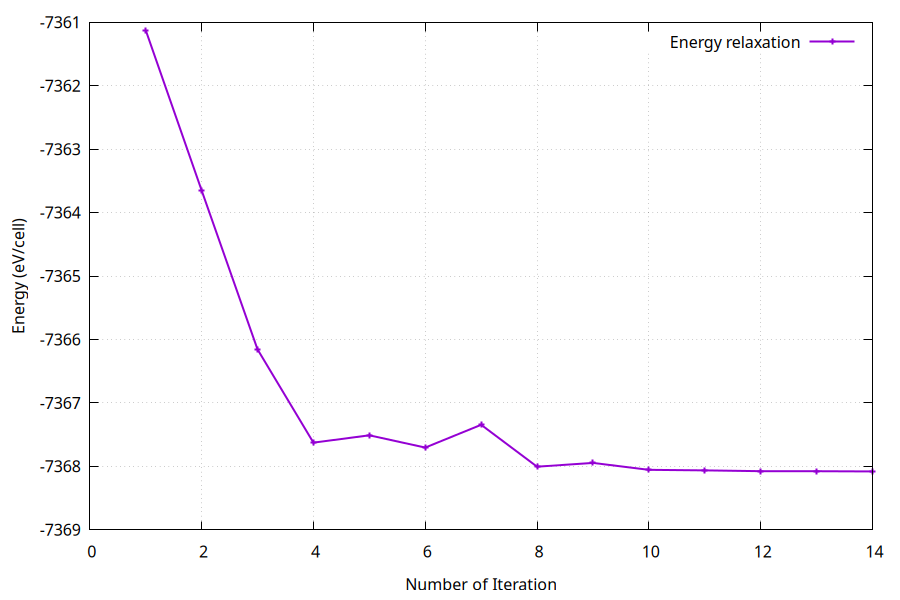

In [29]:
from IPython.display import Image, display
display(Image(filename="energy_iteration.png"))


# EX2: Fast Inertial Relaxation Engine (FIRE) 

In [35]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH


In [31]:
!mkdir -p EX2

In [37]:
%cd EX2

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH/EX2


In [36]:
!cp H.psml  sih.fdf  Si.psml EX2/

In [38]:
ls

H.psml  sih.fdf  Si.psml


In [40]:
!siesta < sih.fdf >sih.out

Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S i

In [41]:
!grep enth sih.out

Target enthalpy (eV/cell)    -7361.1235
Target enthalpy (eV/cell)    -7365.9851
Target enthalpy (eV/cell)    -7367.6327
Target enthalpy (eV/cell)    -7367.8865
Target enthalpy (eV/cell)    -7367.9396
Target enthalpy (eV/cell)    -7367.9905
Target enthalpy (eV/cell)    -7368.0355
Target enthalpy (eV/cell)    -7368.0599
Target enthalpy (eV/cell)    -7368.0589
Target enthalpy (eV/cell)    -7368.0609
Target enthalpy (eV/cell)    -7368.0631
Target enthalpy (eV/cell)    -7368.0660
Target enthalpy (eV/cell)    -7368.0690
Target enthalpy (eV/cell)    -7368.0718
Target enthalpy (eV/cell)    -7368.0742
Target enthalpy (eV/cell)    -7368.0760
Target enthalpy (eV/cell)    -7368.0772
Target enthalpy (eV/cell)    -7368.0777
Target enthalpy (eV/cell)    -7368.0780
Target enthalpy (eV/cell)    -7368.0781
Target enthalpy (eV/cell)    -7368.0783
Target enthalpy (eV/cell)    -7368.0785
Target enthalpy (eV/cell)    -7368.0788
Target enthalpy (eV/cell)    -7368.0790


In [44]:
!tail *.BONDS_FINAL #for converged structure

   45 Si                    2.3478  Ang. Really at:  15.3895 20.5063 15.3895
Neighbors of:    65 H at:  11.5439 11.5439 11.5439
   57 Si                    1.6637  Ang. Really at:   9.7287  9.7287  9.7287
   58 Si                    1.6637  Ang. Really at:  13.3590 13.3590 13.3590
   59 Si                    3.0384  Ang. Really at:  10.1969 15.4906 15.4906
   12 Si                    3.0384  Ang. Really at:  12.8908  7.5972  7.5972
   63 Si                    3.0384  Ang. Really at:  15.4906 15.4906 10.1969
   32 Si                    3.0384  Ang. Really at:   7.5972  7.5972 12.8908
   61 Si                    3.0384  Ang. Really at:  15.4906 10.1969 15.4906
   22 Si                    3.0384  Ang. Really at:   7.5972 12.8908  7.5972


In [45]:
%%bash

# Extract Target enthalpy from SIESTA output
grep "enth" sih.out | awk '{print NR, $NF}' > energy.dat

# Plot using gnuplot
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "energy_iteration.png"
set xlabel "Number of Iteration"
set ylabel "Energy (eV/cell)"
set grid
plot "energy.dat" using 1:2 with linespoints lw 2 title "Energy relaxation"
EOF


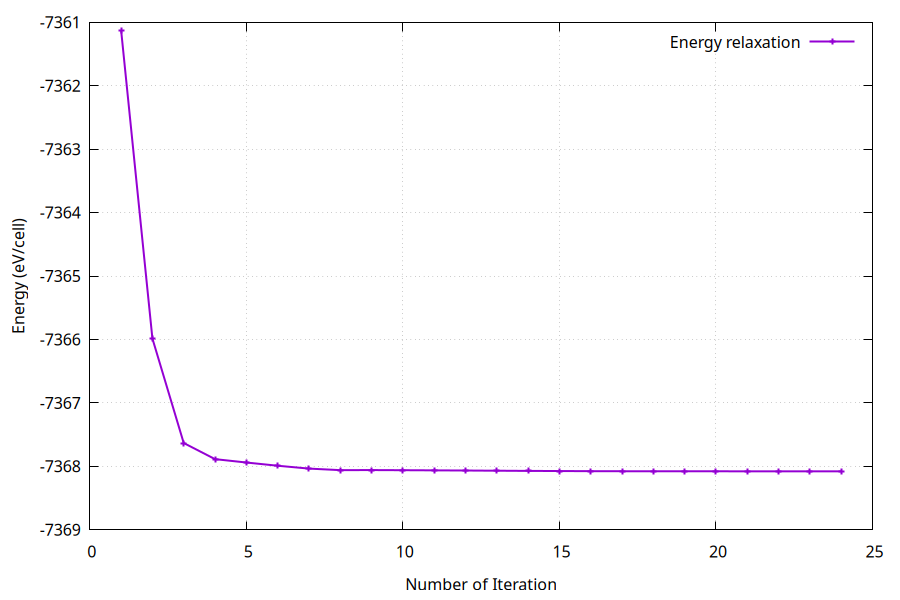

In [46]:
from IPython.display import Image, display
display(Image(filename="energy_iteration.png"))


# EX3:- BROYDEN

In [47]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [48]:
!mkdir -p EX3

In [49]:
!cp H.psml Si.psml sih.fdf EX3/

In [50]:
%cd EX3

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH/EX3


In [51]:
ls

H.psml  sih.fdf  Si.psml


In [52]:
!siesta < sih.fdf >sih.out

Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Job completed


In [53]:
!grep enth sih.out

Target enthalpy (eV/cell)    -7361.1235
Target enthalpy (eV/cell)    -7367.6916
Target enthalpy (eV/cell)    -7367.8792
Target enthalpy (eV/cell)    -7368.0198
Target enthalpy (eV/cell)    -7368.0671
Target enthalpy (eV/cell)    -7368.0762


In [54]:
!tail *.BONDS_FINAL #for converged structure

   45 Si                    2.3483  Ang. Really at:  15.3880 20.5075 15.3880
Neighbors of:    65 H at:  11.5439 11.5439 11.5439
   58 Si                    1.6610  Ang. Really at:  13.3560 13.3560 13.3560
   57 Si                    1.6610  Ang. Really at:   9.7317  9.7317  9.7317
   12 Si                    3.0366  Ang. Really at:  12.8948  7.6003  7.6003
   59 Si                    3.0366  Ang. Really at:  10.1929 15.4874 15.4874
   63 Si                    3.0366  Ang. Really at:  15.4874 15.4874 10.1929
   32 Si                    3.0366  Ang. Really at:   7.6003  7.6003 12.8948
   61 Si                    3.0366  Ang. Really at:  15.4874 10.1929 15.4874
   22 Si                    3.0366  Ang. Really at:   7.6003 12.8948  7.6003


In [55]:
%%bash

# Extract Target enthalpy from SIESTA output
grep "enth" sih.out | awk '{print NR, $NF}' > energy.dat

# Plot using gnuplot
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "energy_iteration.png"
set xlabel "Number of Iteration"
set ylabel "Energy (eV/cell)"
set grid
plot "energy.dat" using 1:2 with linespoints lw 2 title "Energy relaxation"
EOF

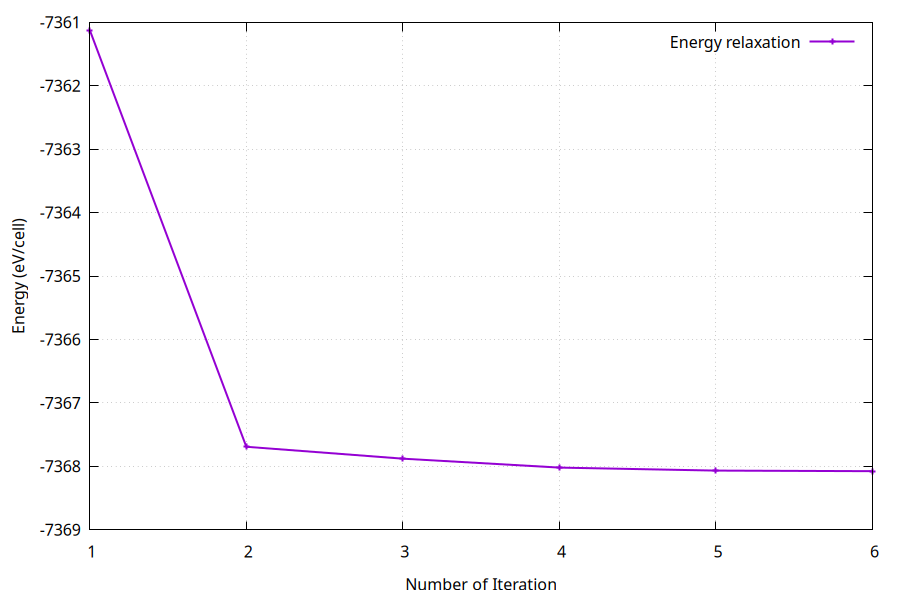

In [56]:
from IPython.display import Image, display
display(Image(filename="energy_iteration.png"))


### EX3.1: Changing the force tolerance

In [57]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH/EX3


In [58]:
!mkdir -p EX3.1

In [59]:
!cp H.psml Si.psml sih.fdf EX3.1/

In [60]:
%cd EX3.1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/01-SiH/EX3/EX3.1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [61]:
ls

H.psml  sih.fdf  Si.psml


In [62]:
!siesta < sih.fdf >sih.out

Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S implicitly performed
Gamma-point calculation with multiply-connected orbital pairs
Folding of H and S i

In [63]:
!tail *.BONDS_FINAL #for converged structure

   51 Si                    2.3485  Ang. Really at:  20.5095 15.3924 15.3924
Neighbors of:    65 H at:  11.5439 11.5439 11.5439
   57 Si                    1.6636  Ang. Really at:   9.7288  9.7288  9.7288
   58 Si                    1.6636  Ang. Really at:  13.3589 13.3589 13.3589
   12 Si                    3.0464  Ang. Really at:  12.8823  7.5848  7.5848
   22 Si                    3.0464  Ang. Really at:   7.5848 12.8823  7.5848
   32 Si                    3.0464  Ang. Really at:   7.5848  7.5848 12.8823
   59 Si                    3.0464  Ang. Really at:  10.2054 15.5030 15.5030
   61 Si                    3.0464  Ang. Really at:  15.5030 10.2054 15.5030
   63 Si                    3.0464  Ang. Really at:  15.5030 15.5030 10.2054


In [64]:
!grep enth sih.out

Target enthalpy (eV/cell)    -7361.1235
Target enthalpy (eV/cell)    -7367.6916
Target enthalpy (eV/cell)    -7367.8792
Target enthalpy (eV/cell)    -7368.0198
Target enthalpy (eV/cell)    -7368.0671
Target enthalpy (eV/cell)    -7368.0762
Target enthalpy (eV/cell)    -7368.0803
Target enthalpy (eV/cell)    -7368.0816
Target enthalpy (eV/cell)    -7368.0830
Target enthalpy (eV/cell)    -7368.0840
Target enthalpy (eV/cell)    -7368.0843


### Effect of Tighter Force Tolerance

Based on previous tests, the **Broyden algorithm** was selected due to its faster convergence compared to CG and FIRE.  
When the force tolerance is tightened to **0.01 eV/Å**, the optimization converges in **10 steps** instead of 6.  
The final energy decreases slightly to **−7368.0843 eV**, about **8.1 meV lower** than before, while the geometry changes are negligible, with atomic displacements well below **0.01 Å**.
